In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def roman_to_int(roman):
    roman_numerals = {'I':1, 'V':5, 'X':10, 'L':50, 'C':100, 'D':500, 'M':1000}
    int_val = 0
    for i in range(len(roman)):
        if i > 0 and roman_numerals[roman[i]] > roman_numerals[roman[i-1]]:
            int_val += roman_numerals[roman[i]] - 2 * roman_numerals[roman[i-1]]
        else:
            int_val += roman_numerals[roman[i]]
    return int_val

def preprocess_real_estate_data(file_path, district_prices_path):
    # Load the data
    df = pd.read_csv(file_path)
    district_prices = pd.read_csv(district_prices_path, sep=';')

    # Extract district number from location with Roman numeral handling
    def extract_district(location):
        if pd.isna(location) or 'kerület' not in str(location):
            return None
        try:
            # Extract Roman numeral between 'Budapest' and 'kerület'
            roman_num = location.split('Budapest')[-1].split('kerület')[0].strip()
            # Handle cases like "VIII. kerület" (with dot) or "VIII kerület" (without dot)
            roman_num = roman_num.replace('.', '').strip()
            return roman_to_int(roman_num)
        except:
            return None

    df['kerület'] = df['location'].apply(extract_district)

    # Preprocess district prices
    district_prices['kerület'] = district_prices['Az ingatlan helye'].str.extract('(\d+)').astype(float)
    district_prices = district_prices[['kerület', 'Lakások összesen átlagár, ezer Ft/m²']]
    district_prices.iloc[:, 1] = district_prices.iloc[:, 1] / 1000
    district_prices = district_prices.rename(columns={'Lakások összesen átlagár, ezer Ft/m²': 'district_avg_price'})
    
    # Merge with district prices
    df = pd.merge(df, district_prices, on='kerület', how='left')
    
    # Calculate price_per_m2 (after merging)
    df['price_per_m2'] = df['price'] / df['area_m2']

    # Outlier removal - keep only within 3 standard deviations
    price_per_m2_mean = df['price_per_m2'].mean()
    price_per_m2_std = df['price_per_m2'].std()
    df = df[(df['price_per_m2'] > price_per_m2_mean - 3*price_per_m2_std) & 
            (df['price_per_m2'] < price_per_m2_mean + 3*price_per_m2_std) &
            (df['price_per_m2'] > 0.3) &
            (df['location'].str.contains("Budapest"))]
    
    # Drop rows with missing price (our target variable)
    df = df.dropna(subset=['price'])
    
    # Drop completely empty columns and URL column (not useful for prediction)
    df = df.drop(columns=['url', 'scrape_date', 'title'])
    
    # Convert price to float (remove any non-numeric characters if needed)
    df['price'] = df['price'].astype(float)
    
    # Simplify location to keep only district (part before comma)
    if 'location' in df.columns:
        df['location'] = df['location'].str.split(',').str[0].str.strip()
    
    # Define categorical and numerical features
    categorical_features = ['floor', 'rooms', 'location', 'Típus', 'Állapot', 'Fűtés', 
                          'Energetikai besorolás', 'Terasz', 'Erkély', 'Napelem']

    # Define categorical and numerical features
    categorical_features = ['floor', 'rooms', 'location', 'Típus', 'Állapot', 'Fűtés', 
                          'Energetikai besorolás', 'Terasz', 'Erkély', 'Napelem']
    numerical_features = ['area_m2', 'Szintek száma', 'Építés éve', 'district_avg_price']
    
    # Special handling for 'Átlagos rezsiköltség' - extract numeric value
    if 'Átlagos rezsiköltség' in df.columns:
        df['Átlagos rezsiköltség'] = df['Átlagos rezsiköltség'].str.extract('(\d+)').astype(float)
        numerical_features.append('Átlagos rezsiköltség')
    
    # Special handling for 'Terasz' and 'Erkély' - extract area if exists
    for col in ['Terasz', 'Erkély']:
        if col in df.columns:
            df[col] = df[col].str.extract('(\d+)').astype(float)
            numerical_features.append(col)
    
    # Create transformers for preprocessing
    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    
    # Combine transformers
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ])
    
    # Apply preprocessing
    X = df.drop(columns=['price', 'price_per_m2'])
    y = df['price_per_m2']
    
    X_processed = preprocessor.fit_transform(X)
    
    # Get feature names after one-hot encoding
    categorical_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    categorical_features_encoded = categorical_encoder.get_feature_names_out(categorical_features)
    feature_names = numerical_features + list(categorical_features_encoded)
    
    return df, X_processed, y, feature_names, district_prices, preprocessor

# Example usage
if __name__ == "__main__":
    file_path = "zenga_listings_details.csv"
    district_prices_path = "Ingatlanadattár, 2023 - Budapest.csv"
    df, X, y, feature_names, district_prices, preprocessor = preprocess_real_estate_data(file_path, district_prices_path)
    
    print("Processed features shape:", X.shape)
    print("Target variable shape:", y.shape)
    print("First 10 feature names:", feature_names[:10])

Processed features shape: (257, 136)
Target variable shape: (257,)
First 10 feature names: ['area_m2', 'Szintek száma', 'Építés éve', 'district_avg_price', 'Átlagos rezsiköltség', 'Terasz', 'Erkély', 'floor_1. emelet', 'floor_10 felett', 'floor_10. emelet']


<>:39: SyntaxWarning: invalid escape sequence '\d'
<>:82: SyntaxWarning: invalid escape sequence '\d'
<>:88: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
<>:82: SyntaxWarning: invalid escape sequence '\d'
<>:88: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Adam\AppData\Local\Temp\ipykernel_15040\3662076940.py:39: SyntaxWarning: invalid escape sequence '\d'
  district_prices['kerület'] = district_prices['Az ingatlan helye'].str.extract('(\d+)').astype(float)
C:\Users\Adam\AppData\Local\Temp\ipykernel_15040\3662076940.py:82: SyntaxWarning: invalid escape sequence '\d'
  df['Átlagos rezsiköltség'] = df['Átlagos rezsiköltség'].str.extract('(\d+)').astype(float)
C:\Users\Adam\AppData\Local\Temp\ipykernel_15040\3662076940.py:88: SyntaxWarning: invalid escape sequence '\d'
  df[col] = df[col].str.extract('(\d+)').astype(float)
C:\Users\Adam\AppData\Local\Temp\ipykernel_15040\3662076940.py:41: FutureWarning: Setting an item of incompati

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Dictionary to store evaluation results
results = {}

In [13]:
# Train and evaluate each model
for name, model in models.items():
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-cv_scores)
    
    # Fit the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    
    # Store results
    results[name] = {
        'CV RMSE Mean': rmse_scores.mean(),
        'CV RMSE Std': rmse_scores.std(),
        'Test MSE': mse,
        'Test RMSE': rmse,
        'Test MAE': mae,
        'Model': model
    }
    
    # Print results
    print(f"----- {name} -----")
    print(f"R² score: {r2_score(y_test, y_pred):.3f}")
    print(f"CV RMSE: {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")
    print(f"Test MSE: {mse:.2f}")
    print(f"Test RMSE: {rmse:.2f}")
    print(f"Test MAE: {mae:.2f}\n")

----- Linear Regression -----
R² score: -2.383
CV RMSE: 1.14 ± 0.19
Test MSE: 0.72
Test RMSE: 0.85
Test MAE: 0.55

----- Random Forest -----
R² score: 0.576
CV RMSE: 0.41 ± 0.06
Test MSE: 0.09
Test RMSE: 0.30
Test MAE: 0.21

----- Gradient Boosting -----
R² score: 0.439
CV RMSE: 0.43 ± 0.06
Test MSE: 0.12
Test RMSE: 0.35
Test MAE: 0.25



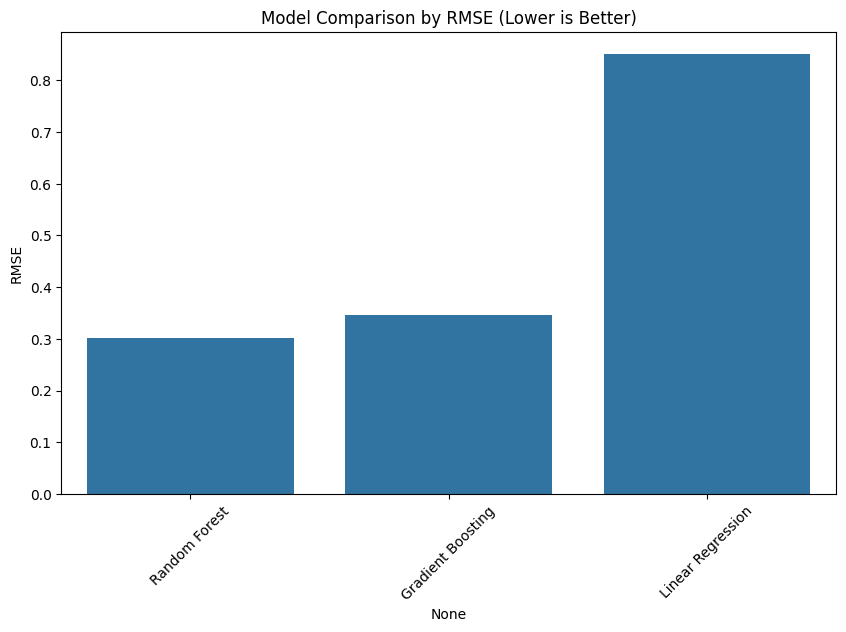

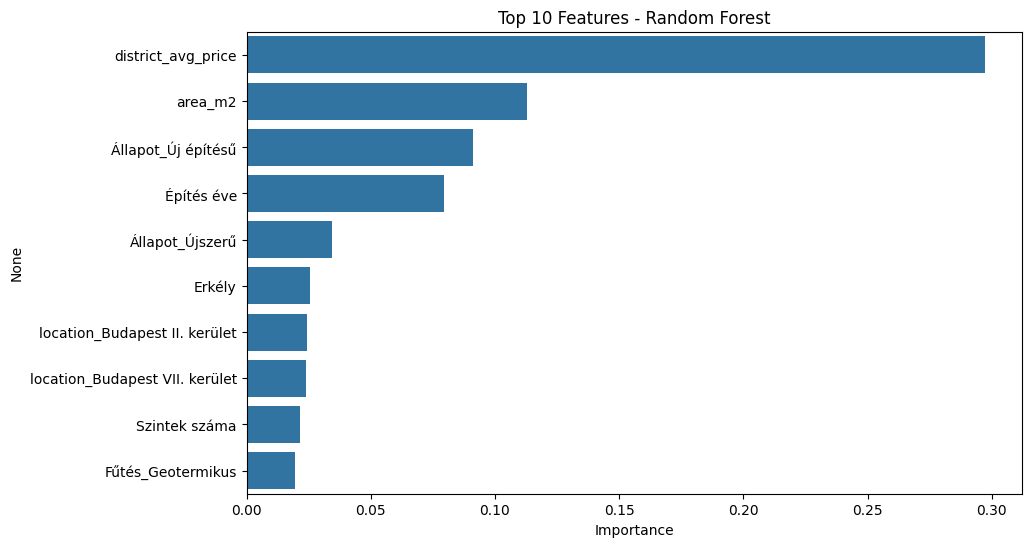

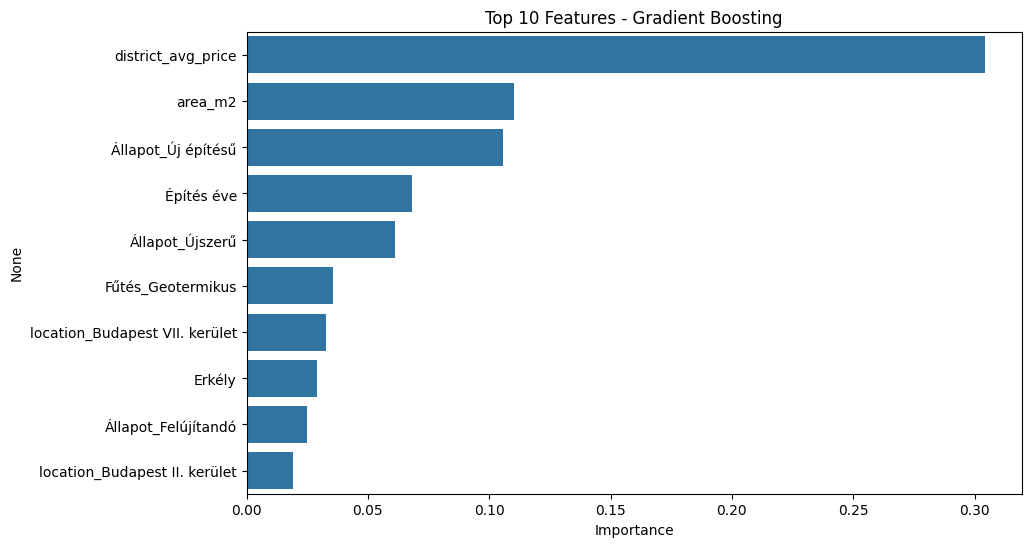

In [14]:
# Create a DataFrame for visualization
results_df = pd.DataFrame.from_dict(results, orient='index')[['Test RMSE', 'Test MAE', 'CV RMSE Mean']]
results_df = results_df.sort_values('Test RMSE')

# Plot performance comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=results_df.index, y=results_df['Test RMSE'])
plt.title('Model Comparison by RMSE (Lower is Better)')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.show()

# Feature importance for tree-based models
for name in ['Random Forest', 'Gradient Boosting']:
    try:
        model = results[name]['Model']
        if hasattr(model, 'feature_importances_'):
            importance = pd.Series(model.feature_importances_, index=feature_names)
            top_features = importance.sort_values(ascending=False).head(10)
            
            plt.figure(figsize=(10, 6))
            sns.barplot(x=top_features.values, y=top_features.index)
            plt.title(f'Top 10 Features - {name}')
            plt.xlabel('Importance')
            plt.show()
    except:
        continue

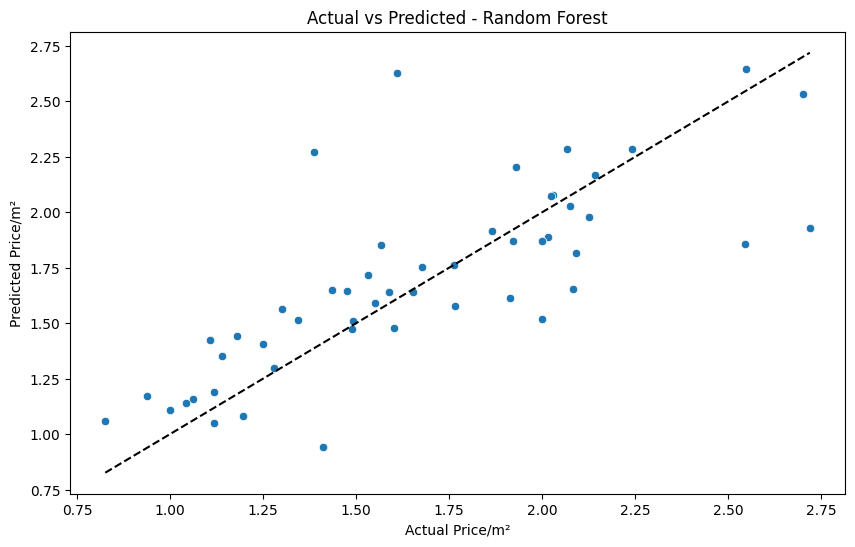

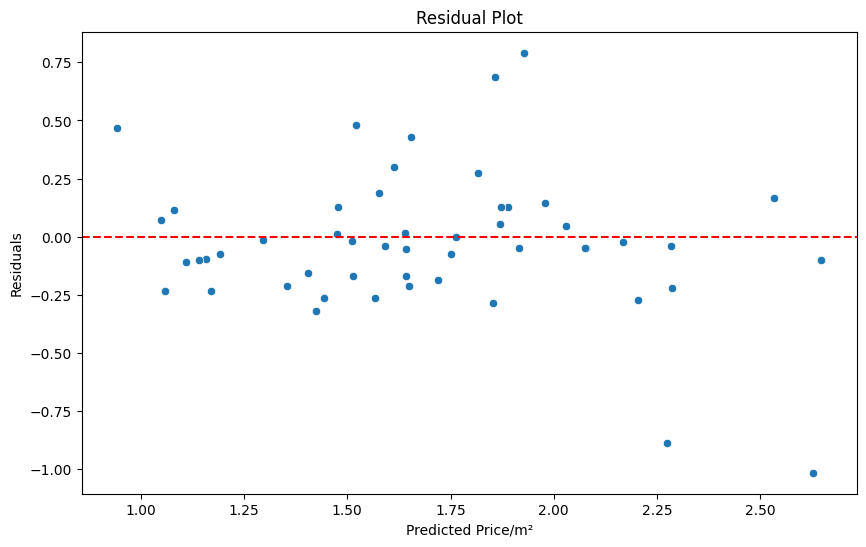

In [15]:
# Plot actual vs predicted values for the best model
best_model_name = min(results, key=lambda x: results[x]['Test RMSE'])
best_model = results[best_model_name]['Model']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=best_model.predict(X_test))
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Actual Price/m²')
plt.ylabel('Predicted Price/m²')
plt.title(f'Actual vs Predicted - {best_model_name}')
plt.show()

# Residual plot
residuals = y_test - best_model.predict(X_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=best_model.predict(X_test), y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price/m²')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [16]:
# Create a DataFrame with errors for further analysis
error_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': best_model.predict(X_test),
    'Error': y_test - best_model.predict(X_test),
    'AbsError': abs(y_test - best_model.predict(X_test))
})

# Display worst predictions
print("Worst Underestimations:")
display(error_df.sort_values('Error').head())

print("\nWorst Overestimations:")
display(error_df.sort_values('Error', ascending=False).head())

# Summary statistics of errors
print("\nError Statistics:")
display(error_df['Error'].describe())

Worst Underestimations:


,Actual,Predicted,Error,AbsError
105,1.610526,2.626816,-1.016290,1.016290
196,1.387097,2.273620,-0.886523,0.886523
38,1.105882,1.425101,-0.319219,0.319219
188,1.566667,1.853252,-0.286586,0.286586
76,1.928571,2.203571,-0.275000,0.275000



Worst Overestimations:


,Actual,Predicted,Error,AbsError
155,2.719298,1.927934,0.791364,0.791364
249,2.543860,1.856807,0.687053,0.687053
197,2.000000,1.520989,0.479011,0.479011
187,1.410256,0.942316,0.467941,0.467941
32,2.081818,1.653285,0.428533,0.428533



Error Statistics:


count    52.000000
mean     -0.024027
std       0.303154
min      -1.016290
25%      -0.173345
50%      -0.044903
75%       0.125403
max       0.791364
Name: Error, dtype: float64

In [30]:
df['Típus'].unique()

array(['Téglalakás', 'Panellakás', 'Egyéb lakás', 'Társasházi lakás',
       'Csúsztatott zsalus lakás'], dtype=object)

In [31]:
from ipywidgets import interact, widgets
import pandas as pd

def predict_price(kerület, alapterület, szobak, emelet, epites_eve, tipus, allapot, energetika, futes, erkely, terasz, szintek):
    # Az inputok alapján DataFrame létrehozása
    input_data = {
        'kerület': [kerület],
        'area_m2': [alapterület],
        'rooms': [szobak],
        'floor': [emelet],
        'Építés éve': [epites_eve],
        'Energetikai besorolás': [energetika],
        'Fűtés': [futes],
        'Erkély': [erkely],
        'Terasz': [terasz],
        'Típus': [tipus],
        'Állapot': [allapot],
        'Napelem': ['Nincs'],  # Alapértelmezett
        'Átlagos rezsiköltség': [30], # Alapértelmezett
        'Szintek száma': [szintek],
        'location': [f'Budapest {kerület}. kerület'],
    }
    
    input_df = pd.DataFrame(input_data)
    
    # Kerületi átlagár hozzáadása
    kerulet_avg = district_prices.loc[district_prices['kerület'] == kerület, 'district_avg_price'].values[0]
    input_df['district_avg_price'] = kerulet_avg
    
    # Azonos preprocesszing mint a tanításnál
    input_processed = preprocessor.transform(input_df)
    
    # Becslés készítése
    predicted_price_m2 = results["Random Forest"]["Model"].predict(input_processed)[0]
    predicted_price_total = predicted_price_m2 * alapterület
    
    # Eredmény kiírása
    print(f"\n\033[1mBecsült négyzetméterár:\033[0m {predicted_price_m2:,.3f} millió Ft/m²")
    print(f"\033[1mBecsült teljes ár:\033[0m {predicted_price_total:,.1f} millió Ft")
    print(f"\033[1mKerületi átlag:\033[0m {kerulet_avg:,.3f} millió Ft/m²")
    print(f"\033[1mÁtlaghoz viszonyított különbség:\033[0m {predicted_price_m2/kerulet_avg-1:+.1%}")

# Interaktív widget létrehozása
interact(
    predict_price,
    kerület=widgets.IntSlider(min=1, max=23, step=1, value=5, description='Kerület:'),
    alapterület=widgets.IntSlider(min=20, max=200, step=5, value=60, description='Alapterület (m²):'),
    szobak=widgets.FloatSlider(min=1, max=6, step=0.5, value=2, description='Szobák:'),
    emelet=widgets.Dropdown(
        options=['földszint', 'félemelet', '1. emelet', '2. emelet', '3. emelet', '4. emelet', '5. emelet', '6. emelet+'],
        value='2. emelet',
        description='Emelet:'
    ),
    epites_eve=widgets.IntSlider(min=1900, max=2025, step=5, value=1990, description='Építés éve:'),
    tipus=widgets.Dropdown(
        options=['Téglalakás', 'Panellakás', 'Egyéb lakás', 'Társasházi lakás', 'Csúsztatott zsalus lakás'],
        value='Panellakás',
        description='Típus:'
    ),
    allapot=widgets.Dropdown(
        options=['Felújítandó', 'Átlagos', 'Jó állapotú', 'Újszerű', 'Felújított', 'Új építésű'],
        value='Jó állapotú',
        description='Állapot:'
    ),
    energetika=widgets.Dropdown(
        options=['A+', 'A', 'B', 'C', 'D', 'E', 'F', 'G'],
        value='C',
        description='Energetika:'
    ),
    futes=widgets.Dropdown(
        options=['Gázkazán', 'Távfűtés', 'Hőszivattyú', 'Konvektor', 'Mennyezeti hűtés-fűtés'],
        value='Távfűtés',
        description='Fűtés:'
    ),
    erkely=widgets.Dropdown(
        options=[0, 5, 10, 15, 20],
        value=0,
        description='Erkély (m²):'
    ),
    terasz=widgets.Dropdown(
        options=[0, 5, 10, 15, 20],
        value=0,
        description='Terasz (m²):'
    ),
    szintek=widgets.IntSlider(min=1, max=15, step=1, value=5, description='Szintek száma:')
)

interactive(children=(IntSlider(value=5, description='Kerület:', max=23, min=1), IntSlider(value=60, descripti…

<function __main__.predict_price(kerület, alapterület, szobak, emelet, epites_eve, tipus, allapot, energetika, futes, erkely, terasz, szintek)>